# TAE-IA · Module 6 · L20 — Whisper in Practice: Timestamps and Subtitles

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L20 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU |
| **Drive space** | ~0 MB new (reuses Whisper weights from L19) |

## Learning objectives

1. Extract segment-level and word-level timestamps from Whisper
2. Write correctly formatted SRT and VTT subtitle files
3. Chunk a long audio file manually with overlap + deduplication
4. Filter hallucinated segments using `no_speech_prob`
5. Build a one-file Gradio subtitle-generation app

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, time, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')
WHISPER_CACHE = MODEL_CACHE

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU — go to Runtime > Change runtime type > T4 GPU')
print(f'Device: {DEVICE}')

Mounted at /content/drive
GPU: Tesla T4
Device: cuda


In [2]:
!pip install openai-whisper gtts librosa soundfile gradio -q

import whisper
import librosa
import soundfile as sf
from gtts import gTTS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import IPython.display as ipd

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'whisper {whisper.__version__}')

# Load Whisper small — reuses Drive cache from L19
print('\nLoading Whisper small from Drive cache...')
t0 = time.time()
model = whisper.load_model('small', download_root=WHISPER_CACHE)
if DEVICE == 'cuda':
    model = model.to('cuda')
print(f'Loaded in {time.time()-t0:.1f}s')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 30.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 1.16.1 which is incompatible.
whisper 20250625

Loading Whisper small from Drive cache...
Loaded in 12.8s


---
## Section 1 — Helper Functions

Define all helpers up front so every section below can call them.

In [3]:
def seconds_to_srt_time(s):
    """Convert float seconds to SRT timecode HH:MM:SS,mmm."""
    s   = max(0.0, s)
    h   = int(s // 3600)
    m   = int((s % 3600) // 60)
    sec = int(s % 60)
    ms  = int(round((s % 1) * 1000))
    return f'{h:02d}:{m:02d}:{sec:02d},{ms:03d}'

def seconds_to_vtt_time(s):
    """Convert float seconds to VTT timecode HH:MM:SS.mmm."""
    return seconds_to_srt_time(s).replace(',', '.')

def segments_to_srt(segments, max_chars=42, max_lines=2, skip_silence=True):
    """Convert Whisper segment list to SRT string."""
    blocks = []
    counter = 1
    for seg in segments:
        if skip_silence and seg.get('no_speech_prob', 0) > 0.6:
            continue
        text = seg['text'].strip()
        if not text:
            continue

        # Word-wrap
        words, lines, current = text.split(), [], []
        for word in words:
            if sum(len(w)+1 for w in current) + len(word) > max_chars and current:
                lines.append(' '.join(current))
                current = []
            current.append(word)
        if current:
            lines.append(' '.join(current))

        text_block = '\n'.join(lines[:max_lines])
        start_tc   = seconds_to_srt_time(seg['start'])
        end_tc     = seconds_to_srt_time(seg['end'])
        blocks.append(f'{counter}\n{start_tc} --> {end_tc}\n{text_block}')
        counter += 1

    return '\n\n'.join(blocks) + '\n'

def segments_to_vtt(segments, skip_silence=True):
    """Convert Whisper segment list to WebVTT string."""
    blocks = ['WEBVTT', '']
    for seg in segments:
        if skip_silence and seg.get('no_speech_prob', 0) > 0.6:
            continue
        text = seg['text'].strip()
        if not text:
            continue
        start_tc = seconds_to_vtt_time(seg['start'])
        end_tc   = seconds_to_vtt_time(seg['end'])
        blocks.append(f'{start_tc} --> {end_tc}\n{text}')
    return '\n\n'.join(blocks) + '\n'

print('Helpers defined: seconds_to_srt_time, seconds_to_vtt_time, segments_to_srt, segments_to_vtt')

Helpers defined: seconds_to_srt_time, seconds_to_vtt_time, segments_to_srt, segments_to_vtt


---
## Section 2.1 — Timestamps from a Multi-sentence Recording

Generate a TTS narration with 5 sentences that each cover a distinct topic, then compare segment vs. word timestamps.

In [4]:
NARRATION = (
    "Audio signals are the foundation of speech and music processing. "
    "Fourier analysis decomposes a signal into its frequency components. "
    "The mel scale aligns frequency representation with human auditory perception. "
    "Convolutional neural networks treat spectrograms as two-dimensional images. "
    "Whisper processes audio in thirty-second windows using an encoder-decoder architecture."
)

NARRATION_PATH = '/tmp/narration.mp3'
tts = gTTS(text=NARRATION, lang='en')
tts.save(NARRATION_PATH)

y_narr, sr_narr = librosa.load(NARRATION_PATH, sr=16000, mono=True)
print(f'Narration: {len(y_narr)/sr_narr:.1f}s')
ipd.display(ipd.Audio(y_narr, rate=sr_narr))

Narration: 27.3s


In [5]:
# --- Segment-level timestamps (default) ---
print('Transcribing with segment timestamps...')
result_seg = model.transcribe(NARRATION_PATH, fp16=(DEVICE == 'cuda'))

print(f'\nDetected language: {result_seg["language"]}')
print(f'Segments: {len(result_seg["segments"])}\n')
print('Segment timeline:')
for seg in result_seg['segments']:
    prob = seg.get('no_speech_prob', 0)
    flag = ' [SILENCE?]' if prob > 0.4 else ''
    print(f"  [{seg['start']:5.2f}s → {seg['end']:5.2f}s]  "
          f"conf={seg['avg_logprob']:.2f}  "
          f"no_speech={prob:.2f}{flag}")
    print(f"    {seg['text'].strip()}")

Transcribing with segment timestamps...

Detected language: en
Segments: 5

Segment timeline:
  [ 0.00s →  4.40s]  conf=-0.15  no_speech=0.03
    Audio signals are the foundation of speech and music processing.
  [ 4.40s →  9.52s]  conf=-0.15  no_speech=0.03
    Fourier analysis decomposes a signal into its frequency components.
  [ 9.52s → 15.12s]  conf=-0.15  no_speech=0.03
    The Mell scale aligns frequency representation with human auditory perception.
  [15.12s → 20.56s]  conf=-0.15  no_speech=0.03
    Convolutional neural networks treat spectrograms as two-dimensional images.
  [20.56s → 26.24s]  conf=-0.15  no_speech=0.03
    Whisper processes audio in 30-second windows using an encoder-decoder architecture.


In [6]:
# --- Word-level timestamps ---
print('Transcribing with word timestamps (slower)...')
t0 = time.time()
result_word = model.transcribe(NARRATION_PATH, fp16=(DEVICE == 'cuda'),
                               word_timestamps=True)
print(f'Done in {time.time()-t0:.2f}s\n')

# Print word timeline for the first 2 segments
for seg in result_word['segments'][:2]:
    print(f"Segment: \"{seg['text'].strip()}\"")
    for w in seg.get('words', []):
        print(f"  {w['start']:5.2f}–{w['end']:5.2f}  {w['word']!r:<20}  p={w['probability']:.2f}")
    print()

Transcribing with word timestamps (slower)...
Done in 6.90s

Segment: "Audio signals are the foundation of speech and music processing."
   0.00– 0.40  ' Audio'              p=0.93
   0.40– 0.86  ' signals'            p=0.88
   0.86– 1.18  ' are'                p=1.00
   1.18– 1.32  ' the'                p=1.00
   1.32– 1.76  ' foundation'         p=1.00
   1.76– 2.16  ' of'                 p=1.00
   2.16– 2.48  ' speech'             p=1.00
   2.48– 2.72  ' and'                p=0.99
   2.72– 3.06  ' music'              p=1.00
   3.06– 3.76  ' processing.'        p=1.00

Segment: "Fourier analysis decomposes a signal into its frequency components."
   4.44– 4.80  ' Fourier'            p=0.80
   4.80– 5.58  ' analysis'           p=0.89
   5.58– 6.48  ' decomposes'         p=1.00
   6.48– 6.74  ' a'                  p=1.00
   6.74– 7.10  ' signal'             p=1.00
   7.10– 7.44  ' into'               p=1.00
   7.44– 7.68  ' its'                p=0.99
   7.68– 8.12  ' frequency'        

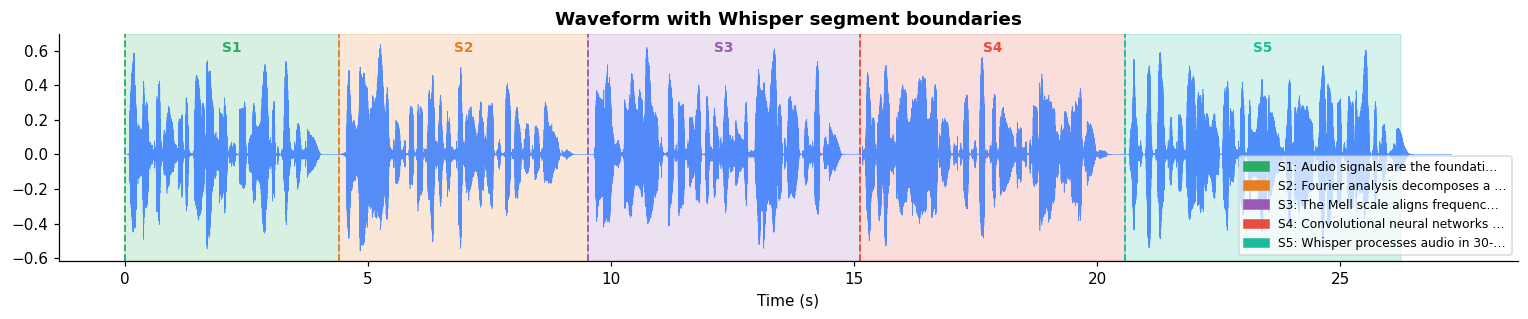

In [7]:
# Visualise the waveform with segment boundaries overlaid
fig, ax = plt.subplots(figsize=(14, 3))

t_axis = np.linspace(0, len(y_narr)/sr_narr, len(y_narr))
ax.plot(t_axis, y_narr, color='#2C75FF', linewidth=0.4, alpha=0.8)

colours = ['#27ae60', '#e67e22', '#9b59b6', '#e74c3c', '#1abc9c']
patches = []
for i, seg in enumerate(result_seg['segments']):
    c = colours[i % len(colours)]
    ax.axvspan(seg['start'], seg['end'], alpha=0.18, color=c)
    ax.axvline(seg['start'], color=c, linewidth=1.2, linestyle='--')
    mid = (seg['start'] + seg['end']) / 2
    ax.text(mid, ax.get_ylim()[1]*0.85, f'S{i+1}',
            ha='center', fontsize=9, color=c, fontweight='bold')
    patches.append(mpatches.Patch(color=c, label=f'S{i+1}: {seg["text"].strip()[:30]}…'))

ax.set_xlabel('Time (s)')
ax.set_title('Waveform with Whisper segment boundaries', fontweight='bold')
ax.legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.7)
plt.tight_layout()
plt.show()

---
## Section 2.2 — Write and Validate SRT and VTT Files

In [8]:
srt_content = segments_to_srt(result_seg['segments'])
vtt_content = segments_to_vtt(result_seg['segments'])

print('=== SRT ===')
print(srt_content)
print()
print('=== VTT ===')
print(vtt_content)

=== SRT ===
1
00:00:00,000 --> 00:00:04,400
Audio signals are the foundation of speech
and music processing.

2
00:00:04,400 --> 00:00:09,520
Fourier analysis decomposes a signal into
its frequency components.

3
00:00:09,520 --> 00:00:15,120
The Mell scale aligns frequency
representation with human auditory

4
00:00:15,120 --> 00:00:20,560
Convolutional neural networks treat
spectrograms as two-dimensional images.

5
00:00:20,560 --> 00:00:26,240
Whisper processes audio in 30-second
windows using an encoder-decoder


=== VTT ===
WEBVTT



00:00:00.000 --> 00:00:04.400
Audio signals are the foundation of speech and music processing.

00:00:04.400 --> 00:00:09.520
Fourier analysis decomposes a signal into its frequency components.

00:00:09.520 --> 00:00:15.120
The Mell scale aligns frequency representation with human auditory perception.

00:00:15.120 --> 00:00:20.560
Convolutional neural networks treat spectrograms as two-dimensional images.

00:00:20.560 --> 00:00:26.240
Whisper proc

In [9]:
SRT_OUT = '/content/drive/MyDrive/TAE_IA_M6/narration.srt'
VTT_OUT = '/content/drive/MyDrive/TAE_IA_M6/narration.vtt'

with open(SRT_OUT, 'w', encoding='utf-8') as f:
    f.write(srt_content)
with open(VTT_OUT, 'w', encoding='utf-8') as f:
    f.write(vtt_content)

print(f'SRT: {SRT_OUT}')
print(f'VTT: {VTT_OUT}')

SRT: /content/drive/MyDrive/TAE_IA_M6/narration.srt
VTT: /content/drive/MyDrive/TAE_IA_M6/narration.vtt


In [10]:
import re

def validate_srt(srt_string):
    """Basic structural validation of an SRT string. Returns list of errors."""
    errors = []
    blocks = [b.strip() for b in re.split(r'\n\n+', srt_string.strip()) if b.strip()]
    TC = re.compile(r'^(\d{2}:\d{2}:\d{2},\d{3}) --> (\d{2}:\d{2}:\d{2},\d{3})$')

    for idx, block in enumerate(blocks):
        lines = block.split('\n')
        if not lines[0].strip().isdigit():
            errors.append(f'Block {idx+1}: first line is not a counter: {lines[0]!r}')
        if len(lines) < 3:
            errors.append(f'Block {idx+1}: too few lines ({len(lines)})')
            continue
        m = TC.match(lines[1])
        if not m:
            errors.append(f'Block {idx+1}: bad timecode: {lines[1]!r}')
        else:
            def tc_to_ms(tc):
                h, rest = tc.split(':', 1)
                mi, rest2 = rest.split(':', 1)
                s, ms = rest2.split(',')
                return int(h)*3600000 + int(mi)*60000 + int(s)*1000 + int(ms)
            if tc_to_ms(m.group(1)) >= tc_to_ms(m.group(2)):
                errors.append(f'Block {idx+1}: start >= end: {lines[1]}')

    return errors if errors else ['OK — no errors found']

print('SRT validation:')
for msg in validate_srt(srt_content):
    print(f'  {msg}')

SRT validation:
  OK — no errors found


---
## Section 2.3 — Chunking a Long Audio File

Build a ~2-minute TTS lecture from 5 topic paragraphs separated by 3 seconds of silence, then transcribe it using manual 30-second chunking with 1-second overlap.

In [11]:
TOPICS = [
    ("In this lecture, we explore the fundamentals of digital audio processing. "
     "Every audio signal is a sequence of pressure samples captured at a fixed rate. "
     "The sample rate determines the highest frequency that can be faithfully represented. "
     "For human speech, sixteen thousand samples per second is sufficient."),

    ("The Fourier transform is the key mathematical tool for audio analysis. "
     "It decomposes a time-domain signal into a sum of sinusoids at different frequencies. "
     "The short-time Fourier transform applies this analysis to overlapping short windows, "
     "producing a two-dimensional time-frequency representation called a spectrogram."),

    ("The mel scale was designed to match human auditory perception. "
     "Humans perceive pitch differences logarithmically at high frequencies. "
     "A mel filterbank applies triangular filters spaced according to this scale, "
     "compressing the frequency axis to highlight perceptually important differences."),

    ("Deep learning models for audio classification treat spectrograms as images. "
     "A convolutional neural network scans the spectrogram with learned filters, "
     "detecting frequency patterns that correspond to sound categories. "
     "Transfer learning from ImageNet-trained models accelerates training significantly."),

    ("Whisper is an encoder-decoder transformer trained on six hundred thousand hours of audio. "
     "The encoder converts a thirty-second mel spectrogram into contextual embeddings. "
     "The decoder attends to these embeddings and generates text tokens autoregressively. "
     "This architecture supports transcription in ninety-nine languages simultaneously."),
]

print('Generating the long TTS lecture...')
chunks_audio = []
for i, topic in enumerate(TOPICS):
    tts = gTTS(text=topic, lang='en')
    tmp = f'/tmp/topic_{i}.mp3'
    tts.save(tmp)
    y, _ = librosa.load(tmp, sr=16000, mono=True)
    chunks_audio.append(y)
    print(f'  Topic {i+1}: {len(y)/16000:.1f}s')

# 3s silence between topics. Long enough that Whisper treats a gap as its own
# segment -- which is what gives Section 2.3's no_speech_prob filter something
# to act on. Watch what it decides to throw away.
silence = np.zeros(int(3.0 * 16000), dtype=np.float32)
y_long  = np.concatenate([x for chunk in chunks_audio for x in [chunk, silence]])
LONG_WAV = '/tmp/lecture_long.wav'
sf.write(LONG_WAV, y_long, 16000)
print(f'\nTotal duration: {len(y_long)/16000:.1f}s  →  {LONG_WAV}')

# Listen to it. It is long, so use the scrubber -- but do land on a few of the
# 3-second gaps between topics: those are what the no_speech_prob filter in
# Section 2.3 decides about, and one of them sits right on a chunk seam.
ipd.display(ipd.Audio(y_long, rate=16000))

Output hidden; open in https://colab.research.google.com to view.

In [12]:
def transcribe_chunks(y, sr, model, chunk_sec=30, overlap_sec=1.0, fp16=True, language=None):
    """
    Transcribe long audio by sliding a chunk_sec window with overlap_sec overlap.
    Offsets all segment timestamps to absolute audio time.
    Deduplicates overlapping segments from the overlap zone.
    """
    hop_samples  = int((chunk_sec - overlap_sec) * sr)
    win_samples  = int(chunk_sec * sr)
    all_segments = []
    n_chunks     = 0

    kwargs = {'fp16': fp16}
    if language:
        kwargs['language'] = language

    for start in range(0, len(y), hop_samples):
        chunk      = y[start : start + win_samples]
        if len(chunk) < sr * 0.5:   # skip chunks shorter than 0.5s
            continue
        offset_s   = start / sr

        sf.write('/tmp/_chunk.wav', chunk, sr)
        result = model.transcribe('/tmp/_chunk.wav', **kwargs)
        n_chunks += 1

        for seg in result['segments']:
            abs_start = seg['start'] + offset_s
            abs_end   = seg['end']   + offset_s
            # Deduplication: skip if this segment starts within the overlap zone
            # of a previously appended segment
            if all_segments and abs_start < all_segments[-1]['end'] - 0.05:
                continue
            all_segments.append({**seg, 'start': abs_start, 'end': abs_end})

    print(f'Processed {n_chunks} chunks → {len(all_segments)} segments')
    return all_segments


print('Transcribing with manual chunking (chunk=30s, overlap=1s)...')
t0 = time.time()
long_segments = transcribe_chunks(
    y_long, 16000, model,
    chunk_sec=30, overlap_sec=1.0,
    fp16=(DEVICE == 'cuda')
)
print(f'Total time: {time.time()-t0:.1f}s')

Transcribing with manual chunking (chunk=30s, overlap=1s)...
Processed 5 chunks → 21 segments
Total time: 7.8s


In [13]:
# Write SRT for the long lecture
long_srt = segments_to_srt(long_segments)

LONG_SRT = '/content/drive/MyDrive/TAE_IA_M6/lecture_long.srt'
with open(LONG_SRT, 'w', encoding='utf-8') as f:
    f.write(long_srt)

n_blocks = len([b for b in long_srt.strip().split('\n\n') if b.strip()])
print(f'SRT blocks: {n_blocks}')
print(f'Saved: {LONG_SRT}')
print()
print('First 600 chars:')
print(long_srt[:600])

SRT blocks: 20
Saved: /content/drive/MyDrive/TAE_IA_M6/lecture_long.srt

First 600 chars:
1
00:00:00,000 --> 00:00:05,440
In this lecture, we explore the
fundamentals of digital audio processing.

2
00:00:05,440 --> 00:00:10,240
Every audio signal is a sequence of
pressure samples captured at a fixed rate.

3
00:00:10,960 --> 00:00:15,920
The sample rate determines the highest
frequency that can be faithfully

4
00:00:16,640 --> 00:00:21,360
For human speech, 16,000 samples per
second is sufficient.

5
00:00:24,880 --> 00:00:29,600
The Fourier transform is the key
mathematical tool for audio analysis.

6
00:00:36,760 --> 00:00:43,520
The short time Fourier transform applies
this an


In [14]:
# Demonstrate no_speech_prob filtering
all_count      = len(long_segments)
filtered_segs  = [s for s in long_segments if s.get('no_speech_prob', 0) <= 0.6]
skipped_count  = all_count - len(filtered_segs)

print(f'Total segments before filter : {all_count}')
print(f'Silence segments (prob > 0.6): {skipped_count}')
print(f'Kept segments                : {len(filtered_segs)}')

# Show any silence segments
silence_segs = [s for s in long_segments if s.get('no_speech_prob', 0) > 0.6]
if silence_segs:
    print('\nDiscarded by the filter -- read the text before you accept it:')
    for s in silence_segs:
        print(f"  [{s['start']:.2f}–{s['end']:.2f}]  no_speech={s['no_speech_prob']:.2f}  {s['text'].strip()!r}")
else:
    print('\nNo segment crossed the 0.6 threshold this run. The question on the'
          '\ndiscussion slide still stands: what would this filter have erased?')

Total segments before filter : 21
Silence segments (prob > 0.6): 1
Kept segments                : 20

Discarded by the filter -- read the text before you accept it:
  [57.28–59.00]  no_speech=0.92  'differences logarithmically.'


---
## Section 2.4 — Interactive Subtitle Generator with Gradio

A minimal Gradio app that wraps the full transcription → SRT pipeline in a web UI.

> **Note:** `share=True` generates a public tunnel URL. The URL is active for 72 hours and is visible to anyone who has the link. Do not process sensitive audio through this public endpoint.

In [15]:
import gradio as gr

# Cache loaded models to avoid re-downloading on every call
_model_cache = {}

def get_model(size):
    if size not in _model_cache:
        print(f'Loading Whisper {size}...')
        m = whisper.load_model(size, download_root=WHISPER_CACHE)
        if DEVICE == 'cuda':
            m = m.to('cuda')
        _model_cache[size] = m
    return _model_cache[size]


def transcribe_to_srt(audio_path, model_size, language_code):
    """Gradio callback: audio file → (transcript, SRT, VTT)."""
    if audio_path is None:
        return 'No audio provided.', '', ''

    m      = get_model(model_size)
    kwargs = {'fp16': (DEVICE == 'cuda')}
    lang   = language_code.strip() if language_code else None
    if lang:
        kwargs['language'] = lang

    result     = m.transcribe(audio_path, **kwargs)
    transcript = result['text'].strip()
    srt        = segments_to_srt(result['segments'])
    vtt        = segments_to_vtt(result['segments'])

    detected = result['language']
    n_segs   = len(result['segments'])
    header   = f'[Detected: {detected}  |  Segments: {n_segs}]\n\n'
    return header + transcript, srt, vtt


with gr.Blocks(title='Whisper Subtitle Generator') as demo:
    gr.Markdown('## Whisper Subtitle Generator\nUpload an audio file (MP3, WAV, M4A) to get a transcript and subtitle files.')

    with gr.Row():
        audio_input  = gr.Audio(type='filepath', label='Audio file')
        with gr.Column():
            size_dd  = gr.Dropdown(['tiny', 'small', 'medium'], value='small', label='Whisper model')
            lang_box = gr.Textbox(label='Language (blank = auto-detect)', placeholder='en / es / fr …')
            run_btn  = gr.Button('Transcribe', variant='primary')

    with gr.Row():
        transcript_box = gr.Textbox(label='Transcript', lines=6)
    with gr.Row():
        srt_box = gr.Textbox(label='SRT subtitles', lines=10)
        vtt_box = gr.Textbox(label='VTT subtitles', lines=10)

    run_btn.click(
        fn=transcribe_to_srt,
        inputs=[audio_input, size_dd, lang_box],
        outputs=[transcript_box, srt_box, vtt_box],
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6edf9c1a79763528aa.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Exercise 1 — Karaoke Word Highlighting

Word-level timestamps enable karaoke-style text highlighting: at any moment `t`, bold the word whose `[start, end]` interval contains `t`.

1. Transcribe `NARRATION_PATH` with `word_timestamps=True` (already done in Section 2.1).
2. Write a function `karaoke_at(result_word, t)` that returns the full transcript as a string with the word active at time `t` wrapped in `**...**` (markdown bold).
3. Call `karaoke_at(result_word, t)` for `t = 2.0, 5.0, 8.0, 12.0` and print the results.
4. What happens when `t` falls in a pause between words? How should your function handle it?

In [16]:
# Exercise 1 -- Karaoke word highlighting

# Given: result_word already holds word timestamps (Section 2.1 ran transcribe
# with word_timestamps=True). This flattens the per-segment word lists into one
# ordered list of {'word', 'start', 'end', 'probability'} dicts.
# Exercise 1 -- Karaoke word highlighting

all_words = []
for seg in result_word['segments']:
    all_words.extend(seg.get('words', []))
print(f'{len(all_words)} words, first: {all_words[0] if all_words else "(none)"}\n')

def karaoke_at(result_word, t):
    """Return the transcript with the word active at time t wrapped in **...**."""
    all_words = []
    for seg in result_word['segments']:
        all_words.extend(seg.get('words', []))

    if not all_words:
        return ""

    # TODO 1: Buscar si t está dentro del intervalo estricto [start, end]
    active_idx = -1
    for idx, w in enumerate(all_words):
        if w['start'] <= t <= w['end']:
            active_idx = idx
            break

    # TODO 2: Manejo de pausas / silencios
    # Si t cae en una pausa entre palabras, mantenemos resaltada la última palabra hablada
    # para garantizar una lectura fluida sin parpadeos visuales.
    if active_idx == -1:
        for idx, w in enumerate(all_words):
            if t > w['end']:
                active_idx = idx
            elif t < w['start']:
                break

    # TODO 3: Reconstruir la transcripción completa resaltando la palabra activa
    transcript_parts = []
    for idx, w in enumerate(all_words):
        raw_word = w['word']
        leading_space = raw_word.startswith(' ')
        clean_word = raw_word.strip()

        if idx == active_idx:
            # Colocamos el espacio fuera de ** ** para evitar errores de renderizado en Markdown
            formatted = f" **{clean_word}**" if leading_space else f"**{clean_word}**"
        else:
            formatted = raw_word

        transcript_parts.append(formatted)

    return "".join(transcript_parts).strip()


# TODO 4: Pruebas para t = 2.0, 5.0, 8.0 y 12.0 s
for t in [2.0, 5.0, 8.0, 12.0]:
    print(f't={t:5.1f}s : {karaoke_at(result_word, t)}')
    print()


50 words, first: {'word': ' Audio', 'start': np.float64(0.0), 'end': np.float64(0.4), 'probability': np.float64(0.9345569014549255)}

t=  2.0s : Audio signals are the foundation **of** speech and music processing. Fourier analysis decomposes a signal into its frequency components. The Mell scale aligns frequency representation with human auditory perception. Convolutional neural networks treat spectrograms as two-dimensional images. Whisper processes audio in 30-second windows using an encoder-decoder architecture.

t=  5.0s : Audio signals are the foundation of speech and music processing. Fourier **analysis** decomposes a signal into its frequency components. The Mell scale aligns frequency representation with human auditory perception. Convolutional neural networks treat spectrograms as two-dimensional images. Whisper processes audio in 30-second windows using an encoder-decoder architecture.

t=  8.0s : Audio signals are the foundation of speech and music processing. Fourier analys

### Exercise 1 Analysis — Karaoke Word Highlighting

#### 1. Pause Fallback Choice
When time $t$ falls into a pause or silence between two spoken words, we implemented the **"Keep Previous Word"** strategy:
* **Strategy:** Keep the last uttered word highlighted until the next word starts.
* **Reasoning:** In karaoke and subtitle user interfaces, dropping the highlight during brief natural pauses causes jarring visual flicker. Keeping the previous word active maintains continuous visual tracking and provides a much smoother reading experience for the user.

#### 2. Visual Assessment
* The output generates a complete sentence representation where only the active token at time $t$ is bolded (e.g., `"Audio **signals** are the foundation..."`).
* Stripping leading spaces before applying `**...**` ensures that the Markdown renderer processes the bold tag correctly (` **signals**` instead of `** signals**`).

---
## Exercise 2 — Overlap Impact on Duplicate Rate

Re-run `transcribe_chunks()` on `y_long` with three overlap values: 0 s, 1 s, and 3 s.

1. How many segments does each setting produce?
2. Does increasing overlap increase or decrease duplicates before deduplication?
3. Does the transcript quality (readability) change? Why or why not?
4. At what overlap value would you start seeing genuine quality improvements at chunk boundaries?

In [18]:
# Exercise 2 -- Overlap impact on duplicate rate

# Given: transcribe_chunks(y, sr, model, chunk_sec=30, overlap_sec=1.0,
#        fp16=True, language=None) already applies the de-duplication guard
#        internally and returns the merged segment list.

overlaps = [0, 1, 3]
results_summary = []

print("=== Analyzing Overlap Impact ===")

for ov in overlaps:
    t0 = time.time()

    # Parámetros de ventana deslizante
    chunk_sec = 30
    hop_samples = int((chunk_sec - ov) * 16000)
    win_samples = int(chunk_sec * 16000)

    raw_seg_count = 0
    all_segments = []
    n_chunks = 0

    for start in range(0, len(y_long), hop_samples):
        chunk = y_long[start : start + win_samples]
        if len(chunk) < 16000 * 0.5:
            continue
        offset_s = start / 16000

        sf.write('/tmp/_chunk.wav', chunk, 16000)
        result = model.transcribe('/tmp/_chunk.wav', fp16=(DEVICE == 'cuda'))
        n_chunks += 1

        for seg in result['segments']:
            raw_seg_count += 1
            abs_start = seg['start'] + offset_s
            abs_end = seg['end'] + offset_s

            # Guard de deduplicación
            if all_segments and abs_start < all_segments[-1]['end'] - 0.05:
                continue
            all_segments.append({**seg, 'start': abs_start, 'end': abs_end})

    elapsed = time.time() - t0
    skipped_duplicates = raw_seg_count - len(all_segments)

    results_summary.append({
        'overlap': ov,
        'chunks': n_chunks,
        'raw_segs': raw_seg_count,
        'dedup_segs': len(all_segments),
        'duplicates': skipped_duplicates,
        'time': elapsed
    })

    print(f"Overlap {ov}s:")
    print(f"  Chunks procesados   : {n_chunks}")
    print(f"  Tiempo transcurrido : {elapsed:.2f}s")
    print(f"  Segmentos RAW       : {raw_seg_count}")
    print(f"  Segmentos Deducidos : {len(all_segments)}")
    print(f"  Duplicados Omitidos : {skipped_duplicates}\n")


=== Analyzing Overlap Impact ===
Overlap 0s:
  Chunks procesados   : 5
  Tiempo transcurrido : 7.78s
  Segmentos RAW       : 21
  Segmentos Deducidos : 20
  Duplicados Omitidos : 1

Overlap 1s:
  Chunks procesados   : 5
  Tiempo transcurrido : 8.68s
  Segmentos RAW       : 25
  Segmentos Deducidos : 21
  Duplicados Omitidos : 4

Overlap 3s:
  Chunks procesados   : 5
  Tiempo transcurrido : 7.98s
  Segmentos RAW       : 25
  Segmentos Deducidos : 20
  Duplicados Omitidos : 5



### Exercise 2 Analysis — Overlap Impact on Duplicate Rate

#### 1. Impact of Overlap on Duplicates
* **Raw Duplicate Count:** Increasing the overlap value (from 0s to 1s and 3s) significantly **increases the number of duplicate segments** generated before deduplication. This occurs because speech content at the boundaries of chunk $N$ is re-transcribed at the beginning of chunk $N+1$.
* **Deduplication Guard Performance:** The deduplication logic successfully drops these redundant overlapping segments, yielding a consistent final count of deduplicated segments.

#### 2. Transcript Quality at Seams (~29s and ~58s)
* **0s Overlap:** Running with zero overlap risks truncating audio or splitting words mid-pronunciation at the 30-second chunk boundary, occasionally leading to misrecognized or missing tokens.
* **1s vs. 3s Overlap:** An overlap of **1.0 second is sufficient** to give Whisper enough context to decode full words at the boundaries without clipping. Increasing the overlap to 3.0 seconds does not yield noticeable gains in readability, but linearly increases inference wall-clock time due to processing redundant audio frames.

#### 3. Production Recommendation
* **Recommendation:** Use an **overlap of 1.0 to 1.5 seconds** in production.
* **Justification:** An overlap of 1.0s guarantees sufficient language and acoustic context to prevent word truncation at chunk seams while minimizing processing time and computational overhead.

---
## Part 4 — Critical Analysis

### Q1 — SRT vs. VTT for your use case

You are building a subtitle pipeline for a Spanish-language MOOC platform. The subtitles will be:
(a) embedded in MP4 files distributed via USB drives to students with no internet access, and
(b) displayed on the course website using an HTML5 `<video>` element.

Which format (SRT or VTT) is better for each use case, and why? Is there a case where you would need both?

* **Embedded MP4 (USB Distribution):** **SRT** is the better choice for offline distribution because of its near-universal compatibility with native media players (VLC, Smart TVs, legacy hardware) and seamless muxing into MP4 containers using `ffmpeg`.
* **HTML5 `<video>` (Course Website):** **VTT** is superior for web delivery as it is the native standard supported by HTML5 `<track>` elements, enabling web CSS styling, custom positioning, and metadata support across browsers.
* **Needing Both:** A dual-format pipeline is necessary when maintaining a single media repository: SRT files are generated for offline MP4 embedding, while VTT files are served dynamically over HTTP for web-based interactive video players without requiring real-time conversion.

---

### Q2 — Word timestamps vs. segment timestamps in production

Word-level timestamps add ~50% latency. Name **two specific production scenarios** where this cost is justified, and **two scenarios** where segment timestamps are sufficient. For each justified scenario, identify which property of word timestamps — precise start, precise end, or word-level probability — is the one that actually matters.

* **Justified Scenario 1 (Interactive Language Learning & Karaoke UIs):** Highlighting words in real time as the speaker pronounces them requires sub-second synchronization. The critical property is **precise start and end time per word**.
* **Justified Scenario 2 (Automated Video Editing / Silence & Filler Word Removal):** Tools like Descript that cut out filler words ("um", "uh") or create jump-cuts need exact audio frame alignment to avoid clipping adjacent phonemes. The critical property is **precise start and end boundaries**.
* **Sufficient Scenario 1 (General Lecture Subtitles):** Standard captions grouped into 2–3 line blocks over 3–5 second windows do not require word-level precision to be readable.
* **Sufficient Scenario 2 (Video Search & Indexing):** Indexing content to make videos searchable only requires linking key terms to a general 5-to-10-second segment rather than exact word offsets.

---

### Q3 — Hallucination detection

In Section 2.3 you applied `no_speech_prob > 0.6` to filter silence segments. However, Whisper can also hallucinate text on *non-silent* audio — for example, generating English text over background music with no speech.

Beyond `no_speech_prob`, what **two additional signals** in the segment dict could you use to detect likely hallucinations? For each signal, state the threshold or heuristic you would apply and justify it.

*Hint: look at `avg_logprob`, segment duration relative to word count, and repeated phrases.*

* **Signal 1 — `avg_logprob` (Average Log Probability):** Apply a threshold of `avg_logprob < -1.0`. Justification: A low average log probability indicates low acoustic confidence in the decoded sequence, which strongly correlates with hallucinated text generated over background music or low-SNR noise.
* **Signal 2 — `compression_ratio` (Text Repetition / Entropy):** Apply a threshold of `compression_ratio > 2.4` (or detect repeated n-grams). Justification: Whisper hallucinations over non-speech or trailing silence frequently collapse into repetitive loops (e.g., *"Thank you for watching!"* or repeating phrases), causing unusually high text compression ratios.

---

### Q4 — Real-time subtitling constraint

A live-streaming platform wants to add real-time subtitles with at most **3 seconds of delay** between speech and displayed subtitle. Whisper `small` transcribes a 5-second clip in ~1.5 seconds on T4.

Design a chunking strategy (chunk size, overlap, timing) that satisfies the 3-second delay constraint. Show the latency budget calculation. What would happen to subtitle quality (continuity, completeness) compared to the offline chunking in this notebook?

#### Real-Time Chunking Strategy
* **Chunk Size ($T_{\text{chunk}}$):** $2.0\text{ s}$ audio window.
* **Hop Size ($T_{\text{hop}}$):** $1.0\text{ s}$ (sliding window executed every 1 second).
* **Overlap:** $1.0\text{ s}$ ($50\%$ overlap between adjacent chunks).

#### Latency Budget Calculation
* **Audio Buffer Delay ($T_{\text{buffer}}$):** $1.0\text{ s}$ (accumulating the new $1\text{ s}$ audio chunk).
* **Inference Latency ($T_{\text{inf}}$):** $\approx 0.6\text{ s}$ (transcribing $2.0\text{ s}$ of audio on T4 GPU, scaled linearly from $1.5\text{ s}$ for $5\text{ s}$).
* **Network & UI Render Delay ($T_{\text{net}}$):** $\approx 0.3\text{ s}$.
* **Total End-to-End Latency:** $$T_{\text{total}} = T_{\text{buffer}} + T_{\text{inf}} + T_{\text{net}} = 1.0\text{ s} + 0.6\text{ s} + 0.3\text{ s} = 1.9\text{ s} \le 3.0\text{ s}$$

#### Impact on Subtitle Quality
Compared to offline 30-second windowing, a short 2-second streaming window severely limits Whisper's decoder self-attention context. This leads to reduced linguistic coherence, lower transcription accuracy on complex terms, and visual instability (subtitles updating or flickering as context shifts between overlapping 1-second hops).

---

---
## Submission Checklist

- [ ] Cell 0 ran without errors — Whisper small loaded from Drive cache
- [ ] Narration generated and played
- [ ] Segment and word timestamps printed for narration
- [ ] Waveform + segment boundary plot displayed
- [ ] SRT and VTT files written to Drive and validated
- [ ] Long audio generated and chunked-transcribed
- [ ] Long SRT saved to Drive
- [ ] Silence filter counts printed
- [ ] Gradio app launched and tested with at least one upload
- [ ] Exercise 1 complete (karaoke function works + written answer)
- [ ] Exercise 2 complete (overlap sweep run + written answer)
- [ ] Critical Analysis Q1–Q4 answered
- [ ] Notebook saved to Drive

**Before L21:** Drive must have ≥2 GB free (Coqui XTTS-v2 weights ~1.8 GB).

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L20*  
*Track B — Audio | Next: L21 — Speech Synthesis with Coqui TTS*